# genQC Paper Evaluation

Reproduces the SRV evaluation figure from the genQC paper and compares multiple trained models on the same metric.

**Paper metric**: for each qubit count (3–8), evaluate on the corresponding dataset and compute accuracy per number-of-entangled-qubits bucket. Visualise as one line per qubit count (Oranges colormap).

## 1. Setup

In [1]:
import os, sys, random
from pathlib import Path

import hydra
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra.core.global_hydra import GlobalHydra
from IPython.display import display

from notebooks.shared.bootstrap import setup_notebook_paths

PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import make_artifact_dir, save_dataframe, save_figure, save_json, save_pickle, save_text
from quantum_diffusion.evaluation.evaluator import SRVEvaluator


In [11]:
# -- Edit only this cell -------------------------------------------------------

DATASET_BASE = "./artifacts/datasets/srv-datasets/quditkit"
QUBIT_COUNTS = [3, 4, 5, 6, 7, 8]
SEED = 1234
GUIDANCE_SCALE = 7.5
SAMPLES_PER_BUCKET = 8192  # Paper: 8192
USE_STRATIFIED = True

ARTIFACT_SUBDIR = "srv-text-encoder-ablation"
RUN_NAME = "quditkit_complete"

MODEL_SPECS = [
    {
        "label": "baseline",
        "model_dir": "./artifacts/models/srv-baseline-reproduction/paper_stage_2",
        "hf_repo": None,
    },
    {
        "label": "cloob_rn50",
        "model_dir": "./artifacts/models/srv-text-encoder-ablation/cloob_rn50_stage_2",
        "hf_repo": None,
    },
    {
        "label": "cloob_rn50x4",
        "model_dir": "./artifacts/models/srv-text-encoder-ablation/cloob_rn50x4_stage_2",
        "hf_repo": None,
    },
]

ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, ARTIFACT_SUBDIR, RUN_NAME)


## 2. Evaluate

In [12]:
import ast
from collections import defaultdict
from my_genQC.inference.sampling import generate_tensors as _generate_tensors


def _build_cfg(dataset_path, model_dir, hf_repo, num_samples):
    GlobalHydra.instance().clear()
    with hydra.initialize(version_base=None, config_path="./conf"):
        cfg = hydra.compose(config_name="config.yaml", overrides=["evaluation=paper_srv", f"evaluation.model_params.guidance_scale={GUIDANCE_SCALE}"])
    cfg = cfg["evaluation"]
    cfg.dataset = str(Path(dataset_path).expanduser().resolve())
    cfg.model_dir = str(Path(model_dir).expanduser().resolve()) if model_dir else None
    cfg.hf_repo = hf_repo
    cfg.num_samples = int(num_samples)
    cfg.max_gates = 16
    cfg.save_output = False
    cfg.wandb.enable = False
    return cfg


def _stratified_indices(dataset, samples_per_bucket, seed):
    rng = random.Random(seed)
    bucket_indices = defaultdict(list)
    for i, label in enumerate(dataset.y):
        text = str(label)
        srv = ast.literal_eval(text[text.find("["):text.find("]") + 1])
        bucket_indices[sum(1 for v in srv if v == 2)].append(i)
    idx = []
    for bucket in sorted(bucket_indices):
        pool = bucket_indices[bucket]
        idx.extend(rng.sample(pool, min(samples_per_bucket, len(pool))))
    return idx


def evaluate_model_all_qubits(model_spec, qubit_counts, dataset_base, samples_per_bucket, use_stratified, seed):
    out = {}
    for q in qubit_counts:
        dataset_path = f"{dataset_base}/srv_{q}q_dataset"
        num_samples = samples_per_bucket * q

        cfg = _build_cfg(dataset_path, model_spec.get("model_dir"), model_spec.get("hf_repo"), num_samples)

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        evaluator = SRVEvaluator(config=cfg)

        if use_stratified:
            strat_idx = _stratified_indices(evaluator.dataset, samples_per_bucket, seed)
            evaluator.samples = len(strat_idx)
            evaluator.idx = strat_idx
            prompts = [str(evaluator.dataset.y[i]) for i in strat_idx]
            tensors_out = _generate_tensors(
                pipeline=evaluator.pipeline,
                prompt=prompts,
                samples=evaluator.samples,
                system_size=evaluator.system_size,
                num_of_qubits=evaluator.num_qubits,
                max_gates=evaluator.max_gates,
                g=cfg.model_params.guidance_scale,
                auto_batch_size=cfg.model_params.auto_batch_size,
                enable_params=False,
                no_bar=False,
            )
            decoded = evaluator.decode_tensors(tensors_out)
            _, t_srv, p_srv = evaluator.validate_and_calculate_srvs(decoded, save_output=False)
        else:
            tensors_out = evaluator.generate_tensors(save_output=False)
            decoded = evaluator.decode_tensors(tensors_out)
            _, t_srv, p_srv = evaluator.validate_and_calculate_srvs(decoded, save_output=False)

        srv_exact_match_rate, acc_per_entanglement = evaluator.calculate_metrics(t_srv, p_srv)
        conversion_rate = len(t_srv) / evaluator.samples if evaluator.samples else 0.0

        acc = {k: v for k, v in acc_per_entanglement.items() if v > 0 or k == 0}
        out[q] = {
            "srv_exact_match_rate": srv_exact_match_rate,
            "acc_per_entanglement": acc,
            "conversion_rate": conversion_rate,
        }
        print(f"  {q}q  exact_match={srv_exact_match_rate:.4f}  conversion={conversion_rate:.4f}")
    return out


results = {}
for spec in MODEL_SPECS:
    print(f"\n=== {spec['label']} ===")
    results[spec["label"]] = evaluate_model_all_qubits(
        model_spec=spec,
        qubit_counts=QUBIT_COUNTS,
        dataset_base=DATASET_BASE,
        samples_per_bucket=SAMPLES_PER_BUCKET,
        use_stratified=USE_STRATIFIED,
        seed=SEED,
    )

summary_rows = []
for label, qubit_results in results.items():
    row = {"model": label}
    for q in QUBIT_COUNTS:
        if q in qubit_results:
            r = qubit_results[q]
            row[f"{q}q acc"] = round(r["srv_exact_match_rate"], 4)
            row[f"{q}q conv"] = round(r["conversion_rate"], 4)
        else:
            row[f"{q}q acc"] = float("nan")
            row[f"{q}q conv"] = float("nan")
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("model")

save_pickle(results, ARTIFACT_DIR / "results.pkl")
save_dataframe(summary_df.reset_index(), ARTIFACT_DIR / "summary.csv", index=False)
save_json(
    {
        "dataset_base": DATASET_BASE,
        "qubit_counts": QUBIT_COUNTS,
        "seed": SEED,
        "guidance_scale": GUIDANCE_SCALE,
        "samples_per_bucket": SAMPLES_PER_BUCKET,
        "use_stratified": USE_STRATIFIED,
        "model_specs": MODEL_SPECS,
        "results": results,
    },
    ARTIFACT_DIR / "run_config_and_results.json",
)
save_text(f"Saved SRV evaluation artifacts to {ARTIFACT_DIR}\n", ARTIFACT_DIR / "README.txt")

print(f"\nSaved evaluation artifacts to {ARTIFACT_DIR}")
display(summary_df)



=== baseline ===
[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
2026-04-13 15:16:42 - quantum_diffusion.evaluation.evaluator - INFO - Running w/o wandb
2026-04-13 15:16:42 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_x.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-04-13 15:16:42 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

[INFO]: (generate_comp_tensors) Generated 65536 tensors
2026-04-13 16:01:58 - quantum_diffusion.evaluation.evaluator - INFO - Decoding tensors...
2026-04-13 16:02:24 - quantum_diffusion.evaluation.evaluator - INFO - Finished tensor decoding. Took 25.73 seconds.
2026-04-13 16:02:24 - quantum_diffusion.evaluation.evaluator - INFO - ==== genQC Evaluation ====
2026-04-13 16:02:24 - quantum_diffusion.evaluation.evaluator - INFO - Samples requested: 65536
2026-04-13 16:02:24 - quantum_diffusion.evaluation.evaluator - INFO - Decoded circuits : 62684
2026-04-13 16:02:24 - quantum_diffusion.evaluation.evaluator - INFO - Decode failures  : 2852
2026-04-13 16:02:25 - quantum_diffusion.evaluation.evaluator - INFO - Calculating SRVs...
2026-04-13 16:04:55 - quantum_diffusion.evaluation.evaluator - INFO - Finished SRV calculation. Took 150.39 seconds.
2026-04-13 16:04:55 - quantum_diffusion.evaluation.evaluator - INFO - Calculating metrics...
2026-04-13 16:04:57 - quantum_diffusion.evaluation.evalua

,3q acc,3q conv,4q acc,4q conv,5q acc,5q conv,6q acc,6q conv,7q acc,7q conv,8q acc,8q conv
model,,,,,,,,,,,,
baseline,0.7880,0.9976,0.8372,0.9984,0.8882,0.9975,0.9098,0.9956,0.9197,0.9906,0.9144,0.9857
cloob_rn50,0.7860,0.9974,0.8740,0.9981,0.9267,0.9974,0.9414,0.9922,0.9414,0.9796,0.9373,0.9769
cloob_rn50x4,0.7974,0.9977,0.8848,0.9967,0.9171,0.9888,0.9394,0.9841,0.9457,0.9781,0.9334,0.9565


## 3. Paper Figure

One plot per model. Each line = one qubit count, colour = qubit count (discrete Oranges colormap). This reproduces the figure from the genQC paper.

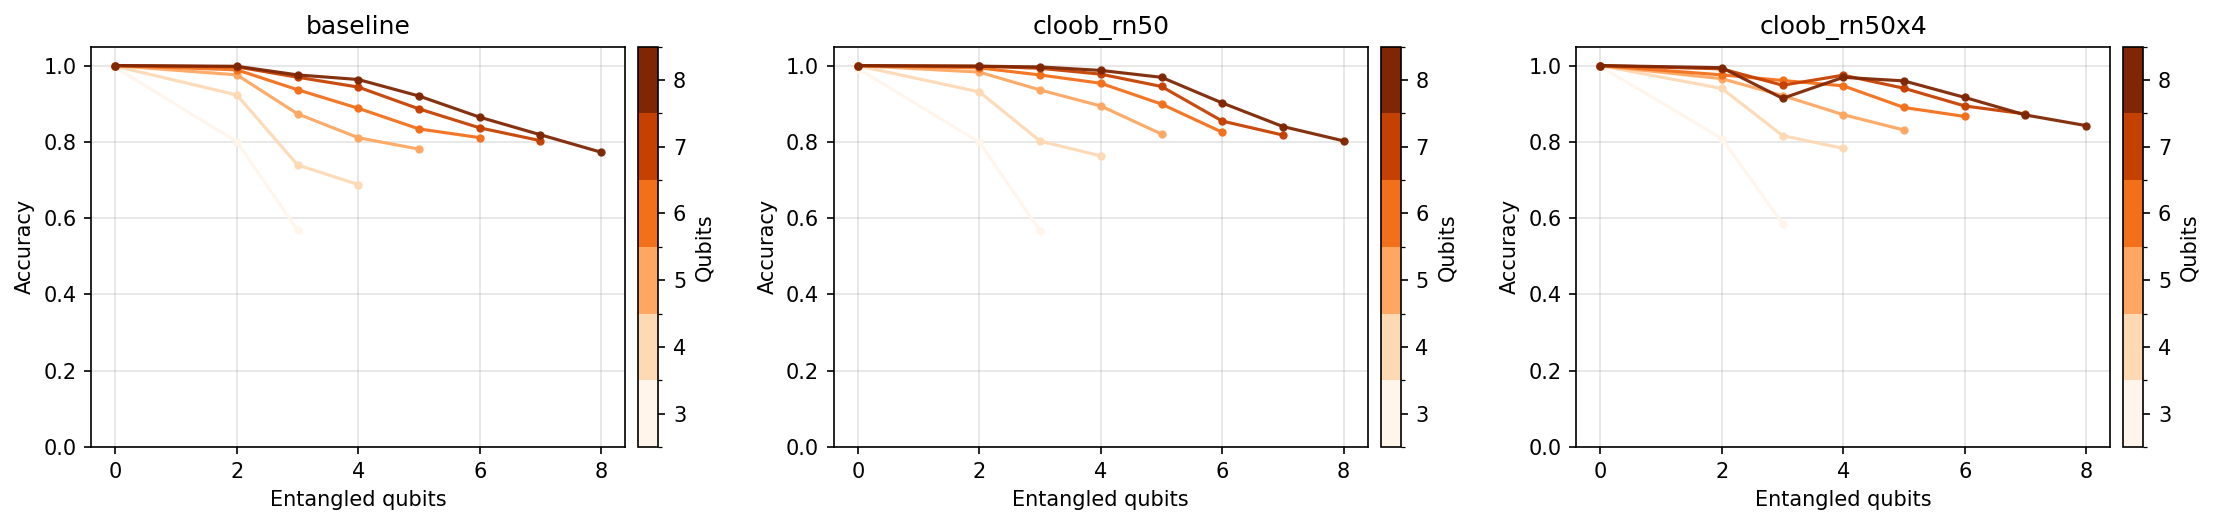

In [13]:
def paper_figure(model_label, qubit_results, ax=None):
    qubits = np.array(sorted(qubit_results.keys()))
    cmap = plt.get_cmap("Oranges", len(qubits))
    bounds = np.arange(qubits.min() - 0.5, qubits.max() + 1.5)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.6), dpi=150)
    else:
        fig = ax.get_figure()

    for q in qubits:
        acc = qubit_results[q]["acc_per_entanglement"]
        xs = sorted(acc.keys())
        ys = [acc[x] for x in xs]
        ax.plot(xs, ys, marker="o", markersize=3, color=cmap(norm(q)), alpha=0.95)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, ticks=qubits, boundaries=bounds)
    cbar.set_label("Qubits")

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Entangled qubits")
    ax.set_ylabel("Accuracy")
    ax.set_title(model_label)
    ax.grid(True, alpha=0.35)
    return fig, ax


n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 3.6), dpi=150, squeeze=False)
for ax, (label, qubit_results) in zip(axes[0], results.items()):
    paper_figure(label, qubit_results, ax=ax)

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "accuracy_by_entanglement_bucket.png")
plt.show()


## 4. Model Comparison

Summary table (exact-match rate per model × qubit count) and a comparison line plot (mean accuracy across entanglement buckets per qubit count).

In [14]:
# Summary table: rows = models, columns = qubit counts.
display(summary_df)


,3q acc,3q conv,4q acc,4q conv,5q acc,5q conv,6q acc,6q conv,7q acc,7q conv,8q acc,8q conv
model,,,,,,,,,,,,
baseline,0.7880,0.9976,0.8372,0.9984,0.8882,0.9975,0.9098,0.9956,0.9197,0.9906,0.9144,0.9857
cloob_rn50,0.7860,0.9974,0.8740,0.9981,0.9267,0.9974,0.9414,0.9922,0.9414,0.9796,0.9373,0.9769
cloob_rn50x4,0.7974,0.9977,0.8848,0.9967,0.9171,0.9888,0.9394,0.9841,0.9457,0.9781,0.9334,0.9565


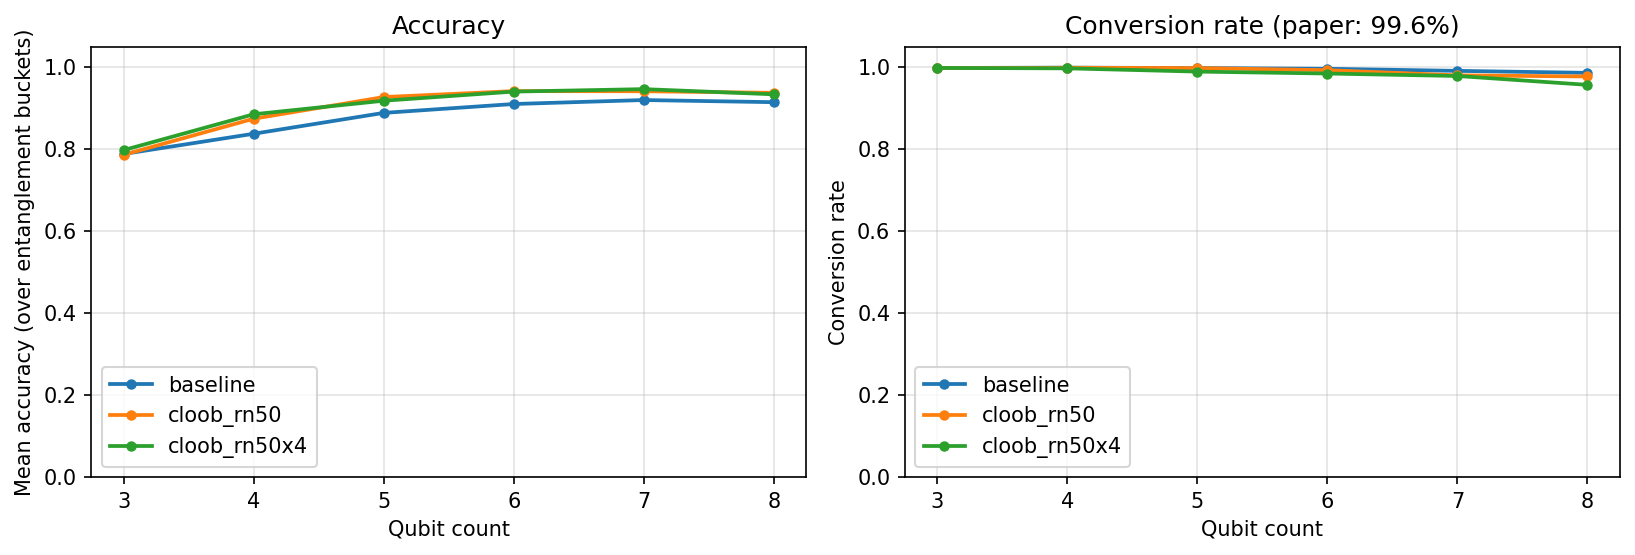

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), dpi=150)

for label, qubit_results in results.items():
    qs = sorted(qubit_results.keys())
    means = [float(np.mean(list(qubit_results[q]["acc_per_entanglement"].values()))) for q in qs]
    convs = [qubit_results[q]["conversion_rate"] for q in qs]
    axes[0].plot(qs, means, marker="o", markersize=4, linewidth=1.8, label=label)
    axes[1].plot(qs, convs, marker="o", markersize=4, linewidth=1.8, label=label)

for ax, ylabel, title in zip(
    axes,
    ["Mean accuracy (over entanglement buckets)", "Conversion rate"],
    ["Accuracy", "Conversion rate (paper: 99.6%)"],
):
    ax.set_xlabel("Qubit count")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(QUBIT_COUNTS)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.35)
    if len(results) > 1:
        ax.legend()

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "summary_comparison.png")
plt.show()
